In [56]:
!pip install tensorflow
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import cifar10

In [10]:
# Load CIFAR-10 dataset from OpenML
cifar10 = fetch_openml('CIFAR_10', version=1)
X, y = cifar10.data, cifar10.target.astype(int)   # convert labels to integers

In [3]:
# Split into 30% train and 70% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42
)

In [4]:
# Scale features (important for correlation and later models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Convert scaled training data into DataFrame with column names
X_train_df = pd.DataFrame(
    X_train_scaled,
    columns=[f"pixel_{i}" for i in range(X_train_scaled.shape[1])]
)

In [7]:
# Basic checks
print(X_train_df.head())
print(X_train_df.info())
print(X_train_df.describe())

    pixel_0   pixel_1   pixel_2   pixel_3   pixel_4   pixel_5   pixel_6  \
0 -0.330391 -0.229782 -0.574653 -0.542680 -0.370784 -0.113094  0.062753   
1  1.691479  1.695196  1.684776  1.685093  1.687908  1.654688  1.637383   
2  0.147754  0.116437  0.783777  1.169921  1.351795  1.626628  1.707679   
3  0.079447 -0.022050  0.367931  0.348429  0.357461  0.349897  0.357996   
4  1.035737  1.044305  1.033284  1.030685  1.043691  1.037368  1.032838   

    pixel_7   pixel_8   pixel_9  ...  pixel_3062  pixel_3063  pixel_3064  \
0 -0.225130 -0.444364 -0.422246  ...   -0.961751   -0.945735   -0.900582   
1  1.630997  1.597690  1.607197  ...    2.071033    2.096949    2.135732   
2  1.701304  1.696272  1.677663  ...    1.914703    1.878500    1.886599   
3  0.337333  0.316125  0.296515  ...    0.445210    0.318149    0.578648   
4  1.026349  1.034365  1.029369  ...   -1.180612   -1.164184   -1.274282   

   pixel_3065  pixel_3066  pixel_3067  pixel_3068  pixel_3069  pixel_3070  \
0   -0.868638  

In [13]:
# Check for missing values
print("Missing values in X_train:", X_train_df.isnull().sum().sum())
print("Training data shape:", X_train_df.shape, y_train.shape)
print("Test data shape:", X_test_scaled.shape, y_test.shape)

Missing values in X_train: 0
Training data shape: (18000, 3072) (18000,)
Test data shape: (42000, 3072) (42000,)


In [14]:
# Randomly select 10 features
random_features = np.random.choice(X_train_df.columns, size=10, replace=False)

In [15]:
# Compute correlation matrix
corr_matrix = X_train_df[random_features].corr()

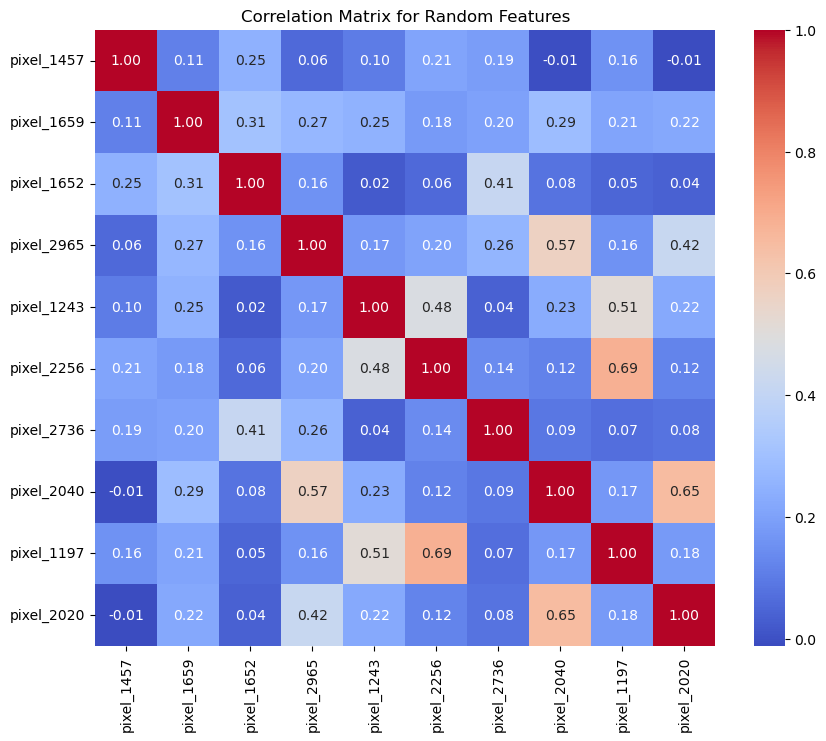

In [16]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix for Random Features")
plt.show()

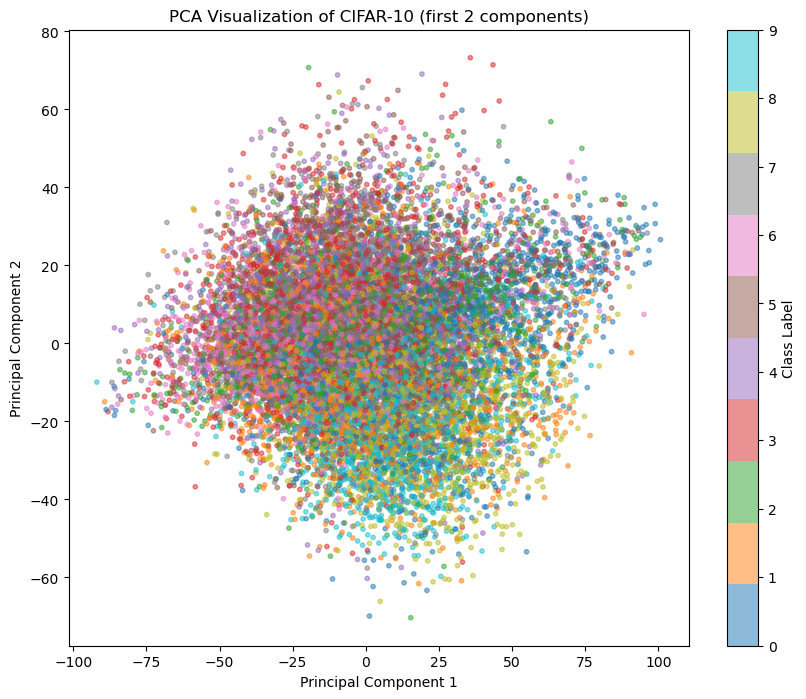

In [17]:
# ===== PCA Visualization =====
pca = PCA(n_components=2)  # reduce to 2D
X_train_pca = pca.fit_transform(X_train_scaled)

# Ensure labels are integers
y_train_int = y_train.astype(int)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train_int, cmap="tab10", alpha=0.5, s=10
)
plt.colorbar(scatter, ticks=range(10), label="Class Label")
plt.title("PCA Visualization of CIFAR-10 (first 2 components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


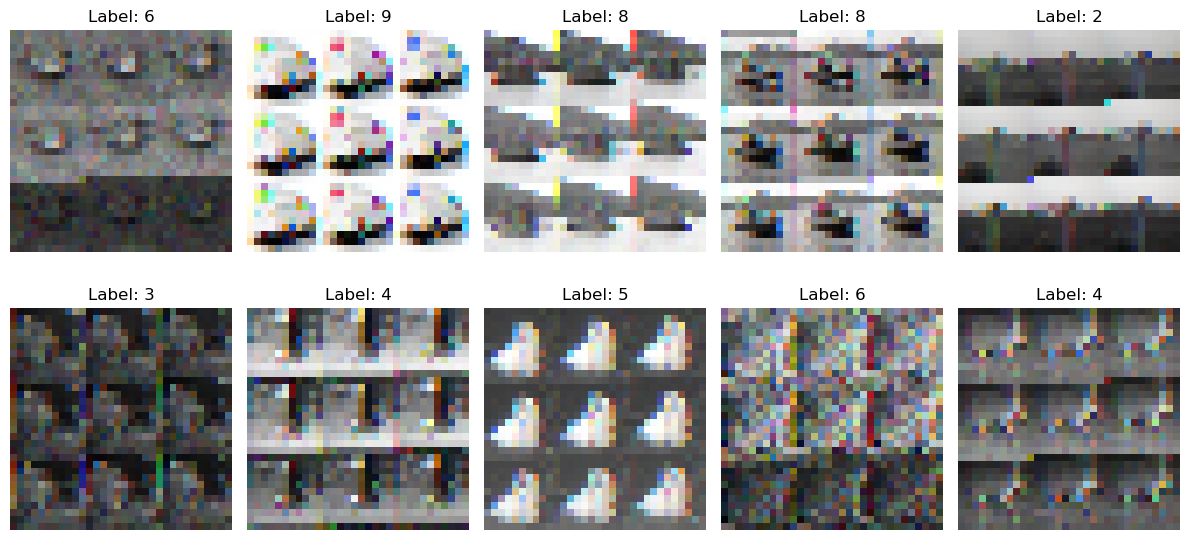

In [19]:
# ===== Show random sample images from training set =====
# Use original (unscaled) X_train from train_test_split
X_train_raw = X_train.copy() if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train)  # ensure DataFrame

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # Use .iloc[i].values to get the i-th row as a NumPy array
    img = X_train_raw.iloc[i].values.reshape(32, 32, 3)
    ax.imshow(img.astype(np.uint8))  # make sure pixel values are integers
    ax.set_title(f"Label: {y_train.iloc[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# ===== Dimensionality Reduction with PCA =====
pca = PCA(n_components=50, random_state=42)  # reduce to 50 components
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

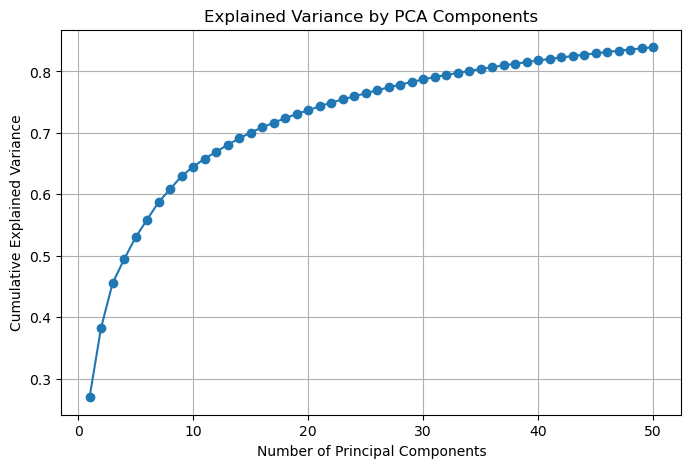

In [21]:
# Optional: check explained variance
explained_var = pca.explained_variance_ratio_.cumsum()
plt.figure(figsize=(8,5))
plt.plot(range(1, 51), explained_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid(True)
plt.show()

In [22]:
# ===== Logistic Regression on PCA features =====
model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
model.fit(X_train_pca, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
# Predictions
y_pred = model.predict(X_test_pca)

In [24]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy (with PCA): {accuracy:.4f}")

Logistic Regression Accuracy (with PCA): 0.3694


In [25]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.44      0.44      4221
           1       0.40      0.40      0.40      4270
           2       0.27      0.23      0.25      4181
           3       0.27      0.25      0.26      4196
           4       0.33      0.29      0.31      4166
           5       0.34      0.34      0.34      4173
           6       0.35      0.41      0.38      4245
           7       0.39      0.36      0.37      4172
           8       0.46      0.50      0.48      4196
           9       0.41      0.47      0.44      4180

    accuracy                           0.37     42000
   macro avg       0.37      0.37      0.37     42000
weighted avg       0.37      0.37      0.37     42000



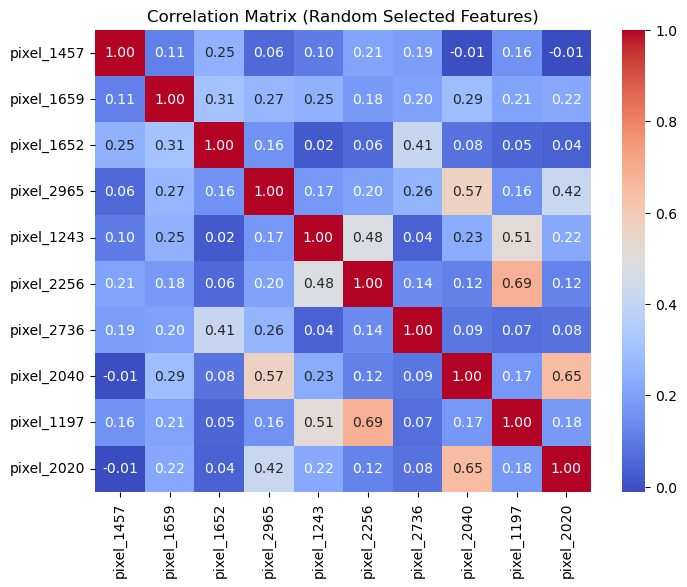

In [26]:
# ===== Optional: Correlation Heatmap for Random Features (scaled) =====
corr_matrix_raw = X_train_df[random_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_raw, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix (Random Selected Features)")
plt.show()

In [27]:
# Normalize / scale training data for correlation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled_corr = scaler.fit_transform(X_train)  # mean=0, std=1
X_train_scaled_corr_df = pd.DataFrame(
    X_train_scaled_corr, 
    columns=[f"pixel_{i}" for i in range(X_train.shape[1])]
)


In [28]:
# Compute correlation of 10 random features
corr_matrix_norm = X_train_scaled_corr_df[random_features].corr()

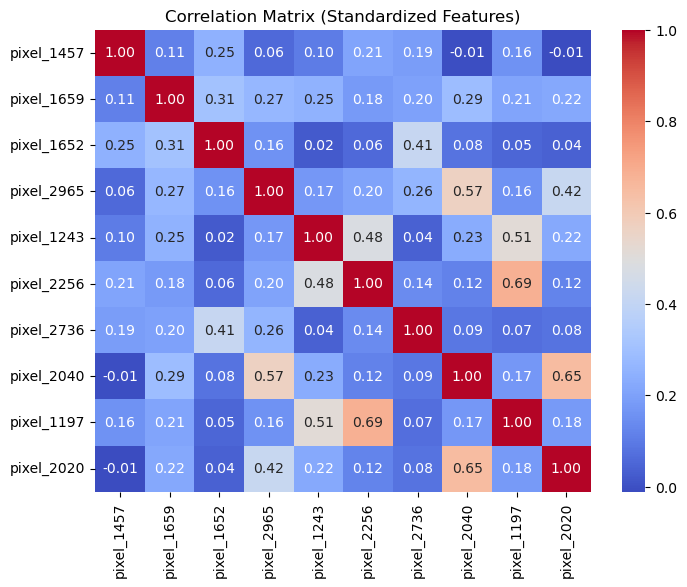

In [29]:
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_norm, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation Matrix (Standardized Features)")
plt.show()

In [30]:
# Apply PCA first
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

In [31]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

In [32]:
# Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(logreg, X_train_pca, y_train, cv=skf, scoring='accuracy')

print("5-Fold Cross Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross Validation Accuracy Scores: [0.365      0.37527778 0.35472222 0.36416667 0.36416667]
Mean Accuracy: 0.3646666666666667
Standard Deviation: 0.0065130448398901504


In [33]:
# Normalize / standardize data
X_unsupervised = X / 255.0  # or use StandardScaler for mean=0, std=1


In [34]:
# Optional: reduce dimensions with PCA first (faster K-Means)
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_unsupervised)

In [35]:
# K-Means clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X_pca50)

KMeans(n_clusters=10, n_init=10, random_state=42)

In [36]:
# ARI evaluation
ari_score = adjusted_rand_score(y.astype(int), kmeans.labels_)
print("Adjusted Rand Index (ARI):", ari_score)

Adjusted Rand Index (ARI): 0.04175820609728183


In [37]:
# PCA for 2D visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2D = pca_2d.fit_transform(X_pca50)

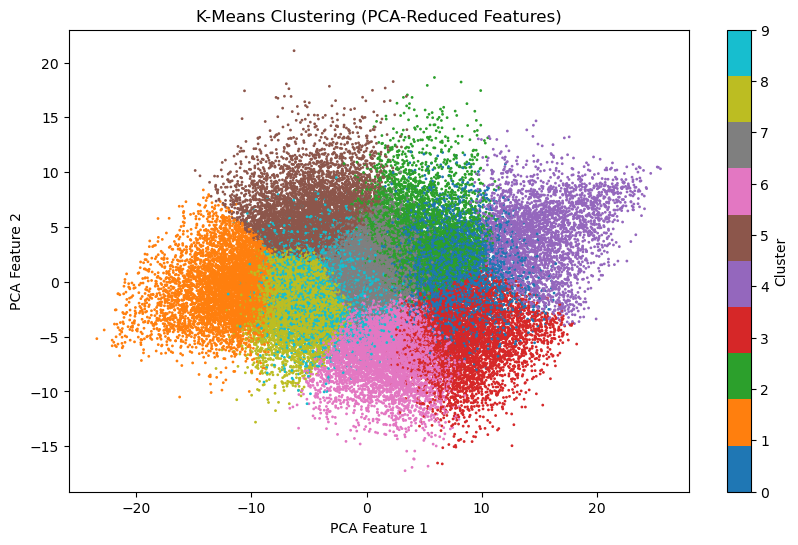

In [40]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=kmeans.labels_, cmap='tab10', s=1)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clustering (PCA-Reduced Features)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()

In [41]:
# Use PCA on the X_train_scaled and X_test_scaled 
pca_50 = PCA(n_components=50, random_state=42)
X_train_pca50 = pca_50.fit_transform(X_train_scaled)  # 18,000 rows
X_test_pca50 = pca_50.transform(X_test_scaled)        # 42,000 rows

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=25, random_state=42, n_jobs=-1)
rf.fit(X_train_pca50, y_train)
rf_pred = rf.predict(X_test_pca50)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.4446428571428571
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.51      4221
           1       0.51      0.51      0.51      4270
           2       0.37      0.28      0.32      4181
           3       0.33      0.25      0.28      4196
           4       0.39      0.40      0.40      4166
           5       0.39      0.39      0.39      4173
           6       0.44      0.51      0.47      4245
           7       0.50      0.44      0.47      4172
           8       0.52      0.62      0.57      4196
           9       0.43      0.54      0.48      4180

    accuracy                           0.44     42000
   macro avg       0.44      0.44      0.44     42000
weighted avg       0.44      0.44      0.44     42000



In [42]:
# PCA with train/test
pca_50 = PCA(n_components=50, random_state=42)
X_train_pca50 = pca_50.fit_transform(X_train_scaled)  # training data
X_test_pca50 = pca_50.transform(X_test_scaled)        # test data

# MLP
mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', max_iter=50, random_state=42)
mlp.fit(X_train_pca50, y_train)
mlp_pred = mlp.predict(X_test_pca50)

print("MLP Accuracy:", accuracy_score(y_test, mlp_pred))
print("MLP Classification Report:")
print(classification_report(y_test, mlp_pred))

MLP Accuracy: 0.4238571428571429
MLP Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.48      0.49      4221
           1       0.53      0.49      0.51      4270
           2       0.32      0.31      0.32      4181
           3       0.28      0.27      0.27      4196
           4       0.33      0.34      0.33      4166
           5       0.34      0.34      0.34      4173
           6       0.44      0.50      0.46      4245
           7       0.48      0.47      0.47      4172
           8       0.56      0.58      0.57      4196
           9       0.47      0.45      0.46      4180

    accuracy                           0.42     42000
   macro avg       0.42      0.42      0.42     42000
weighted avg       0.42      0.42      0.42     42000



C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


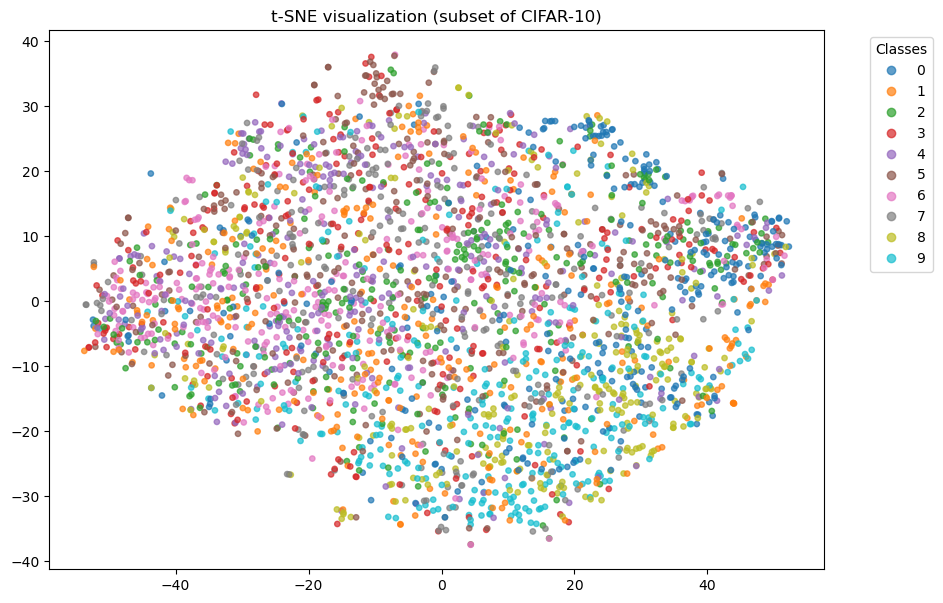

In [44]:
# Subsample 3000 points for speed
idx = np.random.choice(len(X_train_pca), 3000, replace=False)
X_sub = X_train_pca[idx]
y_sub = y_train.iloc[idx]
# Run t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sub)
# Plot
plt.figure(figsize=(10,7))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_sub, cmap='tab10', alpha=0.7, s=15)
plt.legend(*scatter.legend_elements(), title="Classes", bbox_to_anchor=(1.05,1), loc='upper left')
plt.title("t-SNE visualization (subset of CIFAR-10)")
plt.show()


In [ ]:
y_train_cnn = tf.keras.utils.to_categorical(y_train, 10)
y_test_cnn = tf.keras.utils.to_categorical(y_test, 10)

In [57]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Use smaller subset for faster testing
x_train_small = x_train[:5000]
y_train_small = y_train[:5000]
x_test_small = x_test[:1000]
y_test_small = y_test[:1000]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 420s 2us/step


In [59]:
# Normalize pixel values
x_train_small = x_train_small.astype("float32") / 255.0
x_test_small = x_test_small.astype("float32") / 255.0

# One-hot encode labels
y_train_small_cnn = tf.keras.utils.to_categorical(y_train_small, 10)
y_test_small_cnn = tf.keras.utils.to_categorical(y_test_small, 10)

In [63]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Fit on small subset (e.g., 10000 train / 2000 test)
history = model.fit(x_train_small, y_train_small_cnn,
                    epochs=15,
                    batch_size=64,
                    validation_data=(x_test_small, y_test_small_cnn))

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.2702 - loss: 1.9841 - val_accuracy: 0.0900 - val_loss: 2.3054
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3794 - loss: 1.6981 - val_accuracy: 0.0860 - val_loss: 2.3035
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.4318 - loss: 1.5523 - val_accuracy: 0.1030 - val_loss: 2.3035
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.4772 - loss: 1.4448 - val_accuracy: 0.1240 - val_loss: 2.3013
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.5004 - loss: 1.3938 - val_accuracy: 0.1030 - val_loss: 2.3024
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.5410 - loss: 1.2796 - val_accuracy: 0.1690 - val_loss: 2.2784
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.5718 - loss: 1.2195 - val_accuracy: 0.2870 - val_loss: 2.1683
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6034 - loss: 1.1307 - val_accuracy: 0.4030 - v